# Classificação da Faixa de Renda de Adultos

**Etapa 1: Análise Exploratória de Dados (EDA) e pré-processamento**

**Integrantes:** _[Nome 1]_ e _[Nome 2]_

**Data de entrega:** 13/09/2026

**Dataset:** [Adult Income Census (Kaggle)](https://www.kaggle.com/datasets/anaghakp/adult-income-census), redistribuição do dataset *Adult* do UCI Machine Learning Repository, extraído do Censo dos EUA de 1994.

**Objetivo:** prever se a renda anual de uma pessoa é maior que 50 mil dólares (`>50K`) ou não (`<=50K`). É um problema de **classificação binária**.

## 1. Carregamento e inspeção inicial dos dados

### 1.1 Descrição das features

| Variável | Descrição | Tipo |
|---|---|---|
| `age` | Idade em anos | Numérica |
| `workclass` | Tipo de vínculo de trabalho (privado, governo, autônomo...) | Categórica |
| `fnlwgt` | *Final weight*: peso amostral do Censo (quantas pessoas o registro representa). Não descreve a pessoa | Numérica |
| `education` | Nível educacional em texto | Categórica |
| `education_num` | O mesmo nível educacional em número (1 = pré-escola ... 16 = doutorado) | Numérica |
| `marital_status` | Estado civil | Categórica |
| `occupation` | Ocupação | Categórica |
| `relationship` | Papel na família (marido, esposa, filho...) | Categórica |
| `race` | Raça | Categórica |
| `sex` | Sexo | Categórica |
| `capital_gain` | Ganho de capital no ano, em dólares | Numérica |
| `capital_loss` | Perda de capital no ano, em dólares | Numérica |
| `hours_per_week` | Horas trabalhadas por semana | Numérica |
| `native_country` | País de origem | Categórica |
| `income` | Faixa de renda: `<=50K` ou `>50K` | **Alvo** |

Observações iniciais: `education` e `education_num` carregam a mesma informação, e `fnlwgt` é um artefato da amostragem do Censo, não uma característica da pessoa. As duas questões serão tratadas no pré-processamento.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.decomposition import PCA

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

### 1.2 Carregamento

O arquivo `adult.csv` do Kaggle deve estar na mesma pasta do notebook. Se não for encontrado, o mesmo dataset é carregado pelo OpenML. Como versões diferentes do arquivo usam nomes de colunas diferentes, os nomes são padronizados, e o marcador `?` usado pelo dataset para valores ausentes é convertido para `NaN`.

In [2]:
try:
    data = pd.read_csv('adult.csv', skipinitialspace=True)
    print('CSV local carregado.')
except FileNotFoundError:
    from sklearn.datasets import fetch_openml
    data = fetch_openml(name='adult', version=2, as_frame=True, parser='auto').frame
    print('CSV não encontrado: dataset Adult (UCI) carregado pelo OpenML.')

# Padroniza nomes de colunas: minúsculas e underscore.
data.columns = data.columns.str.strip().str.lower().str.replace('-', '_').str.replace('.', '_', regex=False)
data = data.rename(columns={'educational_num': 'education_num', 'gender': 'sex', 'class': 'income'})

# Remove espaços extras nas colunas de texto e trata '?' como ausente.
for col in data.select_dtypes(exclude=np.number).columns:
    data[col] = data[col].astype(str).str.strip().replace({'?': np.nan, 'nan': np.nan})
data['income'] = data['income'].str.replace('.', '', regex=False)  # '>50K.' -> '>50K'

print(f'Instâncias: {data.shape[0]:,} | Features: {data.shape[1] - 1}')
data.head()

CSV não encontrado: dataset Adult (UCI) carregado pelo OpenML.
Instâncias: 48,842 | Features: 14


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


### 1.3 Tipos de dados, valores ausentes e duplicatas

In [3]:
quality = pd.DataFrame({
    'tipo': data.dtypes,
    'ausentes': data.isna().sum(),
    'ausentes_%': (data.isna().mean() * 100).round(2),
    'valores_unicos': data.nunique()
})
display(quality)

print('Duplicatas completas:', data.duplicated().sum())
print('Linhas com workclass E occupation ausentes:', (data['workclass'].isna() & data['occupation'].isna()).sum())

,tipo,ausentes,ausentes_%,valores_unicos
age,int64,0,0.00,74
workclass,object,2799,5.73,8
fnlwgt,int64,0,0.00,28523
education,object,0,0.00,16
education_num,int64,0,0.00,16
marital_status,object,0,0.00,7
occupation,object,2809,5.75,14
relationship,object,0,0.00,6
race,object,0,0.00,5
sex,object,0,0.00,2


Duplicatas completas: 52
Linhas com workclass E occupation ausentes: 2799


**Interpretação**

- São 6 variáveis numéricas (inteiras) e 8 categóricas, além do alvo.
- Só três colunas têm ausentes: `occupation` e `workclass` (cerca de 6% cada) e `native_country` (cerca de 2%).
- `workclass` e `occupation` faltam **nas mesmas linhas**: são pessoas sem vínculo de trabalho declarado. A ausência não é aleatória, ela carrega informação, e isso vai orientar a escolha de imputação.
- Há poucas linhas duplicadas (menos de 0,2%). Elas são removidas para que a mesma linha não caia no treino e no teste ao mesmo tempo, o que inflaria as métricas.

In [4]:
data = data.drop_duplicates().reset_index(drop=True)
print(f'Instâncias após remover duplicatas: {len(data):,}')

Instâncias após remover duplicatas: 48,790


### 1.4 Inconsistências

Não há valores impossíveis (idade negativa, mais de 168 horas por semana etc.). Existem, porém, valores de **teto** definidos pelo Censo: qualquer ganho de capital acima de 99999 foi registrado como 99999, e o mesmo ocorre com 99 horas por semana e 90 anos. Não são erros, então serão mantidos, mas explicam os valores extremos que aparecem nos gráficos.

In [5]:
checks = {
    'capital_gain == 99999 (teto)': (data['capital_gain'] == 99999).sum(),
    'capital_gain > 0': (data['capital_gain'] > 0).sum(),
    'hours_per_week == 99 (teto)': (data['hours_per_week'] == 99).sum(),
    'age == 90 (teto)': (data['age'] == 90).sum(),
}
display(pd.Series(checks, name='quantidade').to_frame())

,quantidade
capital_gain == 99999 (teto),244
capital_gain > 0,4035
hours_per_week == 99 (teto),137
age == 90 (teto),54


### 1.5 Desbalanceamento de classes

,frequencia,percentual
income,,
<=50K,37109,76.06
>50K,11681,23.94


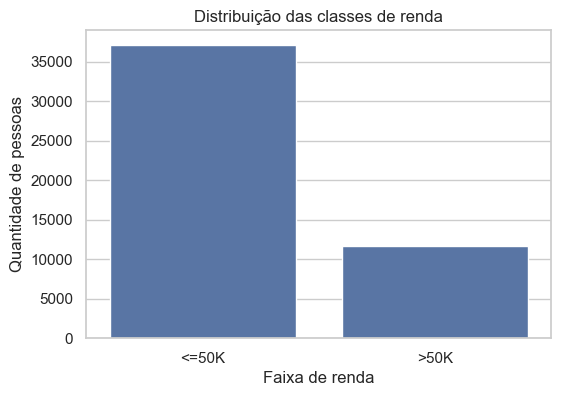

In [6]:
counts = data['income'].value_counts()
display(pd.DataFrame({'frequencia': counts, 'percentual': (counts / len(data) * 100).round(2)}))

plt.figure(figsize=(6, 4))
sns.countplot(data=data, x='income', order=counts.index)
plt.title('Distribuição das classes de renda')
plt.xlabel('Faixa de renda')
plt.ylabel('Quantidade de pessoas')
plt.show()

**Interpretação:** as classes estão desbalanceadas na proporção de cerca de **3:1** (76% `<=50K` e 24% `>50K`). Consequências para a modelagem:

1. A acurácia engana: um modelo que sempre prevê `<=50K` já acerta 76%. As métricas devem ser precisão, recall, F1-score e ROC-AUC.
2. A separação treino/teste deve ser estratificada, e vale testar `class_weight='balanced'` nos modelos.

## 2. Análise univariada

### 2.1 Variáveis numéricas

Foram escolhidas para os gráficos `age`, `hours_per_week` e `capital_gain`, por terem formas bem diferentes. Para `capital_gain`, o histograma mostra só os valores maiores que zero, porque a barra dos zeros esconderia o resto.

,mean,mediana,std,min,max,assimetria
age,38.65,37.0,13.71,17.0,90.0,0.56
fnlwgt,189669.00,178138.5,105617.23,12285.0,1490400.0,1.44
education_num,10.08,10.0,2.57,1.0,16.0,-0.31
capital_gain,1080.22,0.0,7455.91,0.0,99999.0,11.89
capital_loss,87.60,0.0,403.21,0.0,4356.0,4.57
hours_per_week,40.43,40.0,12.39,1.0,99.0,0.24


Percentual de zeros em capital_gain: 91.7 %
Percentual de zeros em capital_loss: 95.3 %


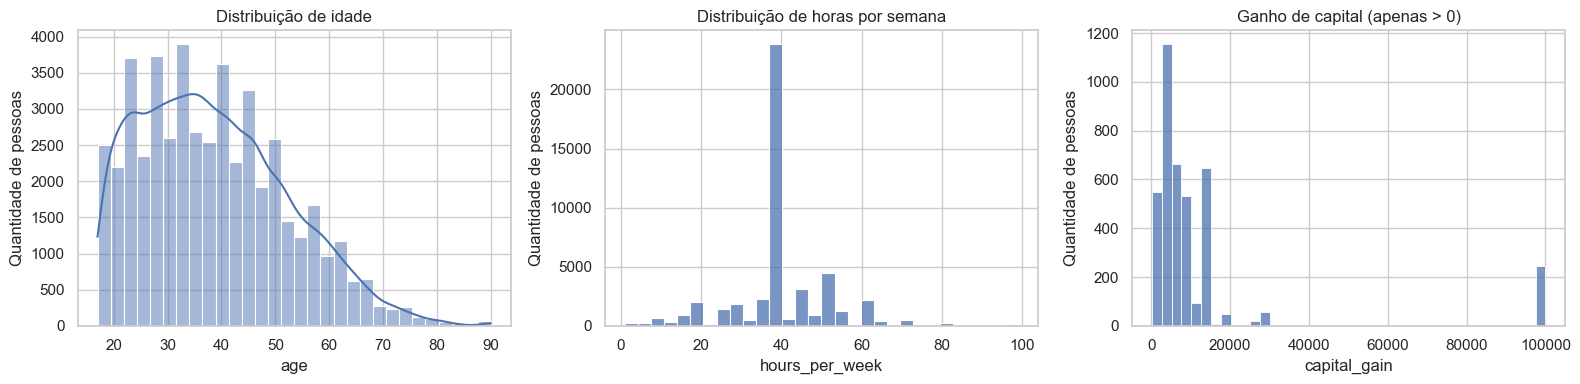

In [7]:
numeric_cols = data.select_dtypes(include=np.number).columns.tolist()
categorical_cols = data.select_dtypes(exclude=np.number).columns.drop('income').tolist()

stats = data[numeric_cols].describe().T[['mean', '50%', 'std', 'min', 'max']].rename(columns={'50%': 'mediana'})
stats['assimetria'] = data[numeric_cols].skew()
display(stats.round(2))
print('Percentual de zeros em capital_gain:', round((data['capital_gain'] == 0).mean() * 100, 1), '%')
print('Percentual de zeros em capital_loss:', round((data['capital_loss'] == 0).mean() * 100, 1), '%')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(data=data, x='age', bins=30, kde=True, ax=axes[0]).set_title('Distribuição de idade')
sns.histplot(data=data, x='hours_per_week', bins=30, ax=axes[1]).set_title('Distribuição de horas por semana')
sns.histplot(data=data[data['capital_gain'] > 0], x='capital_gain', bins=40, ax=axes[2]).set_title('Ganho de capital (apenas > 0)')
for ax in axes:
    ax.set_ylabel('Quantidade de pessoas')
plt.tight_layout()
plt.show()

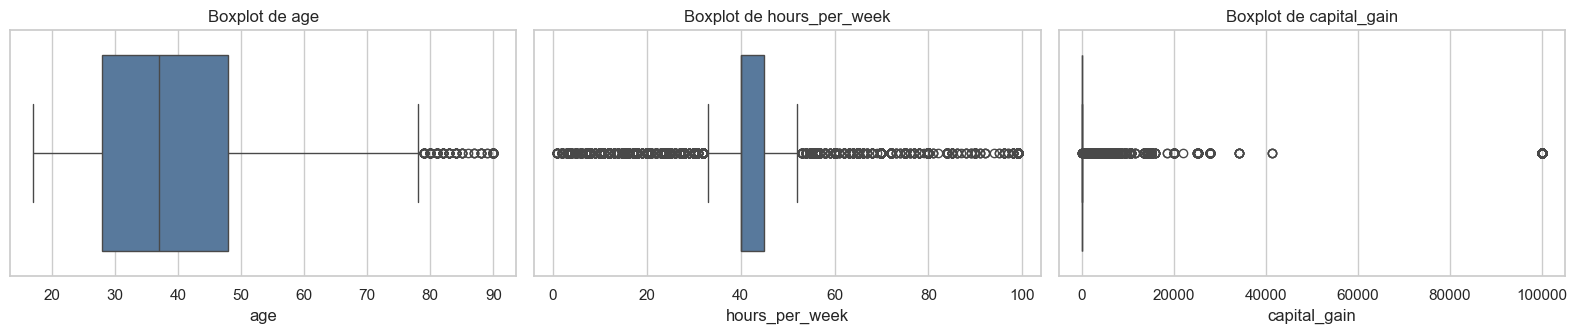

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 3.5))
for ax, col in zip(axes, ['age', 'hours_per_week', 'capital_gain']):
    sns.boxplot(data=data, x=col, ax=ax, color='#4c78a8')
    ax.set_title(f'Boxplot de {col}')
plt.tight_layout()
plt.show()

**Interpretação**

- `age`: assimetria positiva leve, mediana de 37 anos. O boxplot marca idades acima de 78 como outliers, mas são valores plausíveis.
- `hours_per_week`: concentrada em 40 h (jornada padrão). Os muitos pontos fora da caixa são consequência da caixa ser estreita, não erros.
- `capital_gain` e `capital_loss`: mais de 90% dos valores são zero, mediana zero e desvio padrão várias vezes maior que a média (assimetria de 11,9 e 4,6). São as variáveis que mais precisam de transformação de escala.
- `fnlwgt`: grande dispersão, mas não descreve a pessoa.
- `education_num`: entre 1 e 16, mediana 10.

### 2.2 Variáveis categóricas

,frequencia
education,
HS-grad,15770
Some-college,10863
Bachelors,8013
Masters,2656
Assoc-voc,2060
11th,1812
Assoc-acdm,1601
10th,1389
7th-8th,954


,frequencia
occupation,
Prof-specialty,6165
Craft-repair,6102
Exec-managerial,6082
Adm-clerical,5606
Sales,5501
Other-service,4919
Machine-op-inspct,3017
NaN,2805
Transport-moving,2355


,frequencia
marital_status,
Married-civ-spouse,22366
Never-married,16082
Divorced,6630
Separated,1530
Widowed,1518
Married-spouse-absent,627
Married-AF-spouse,37


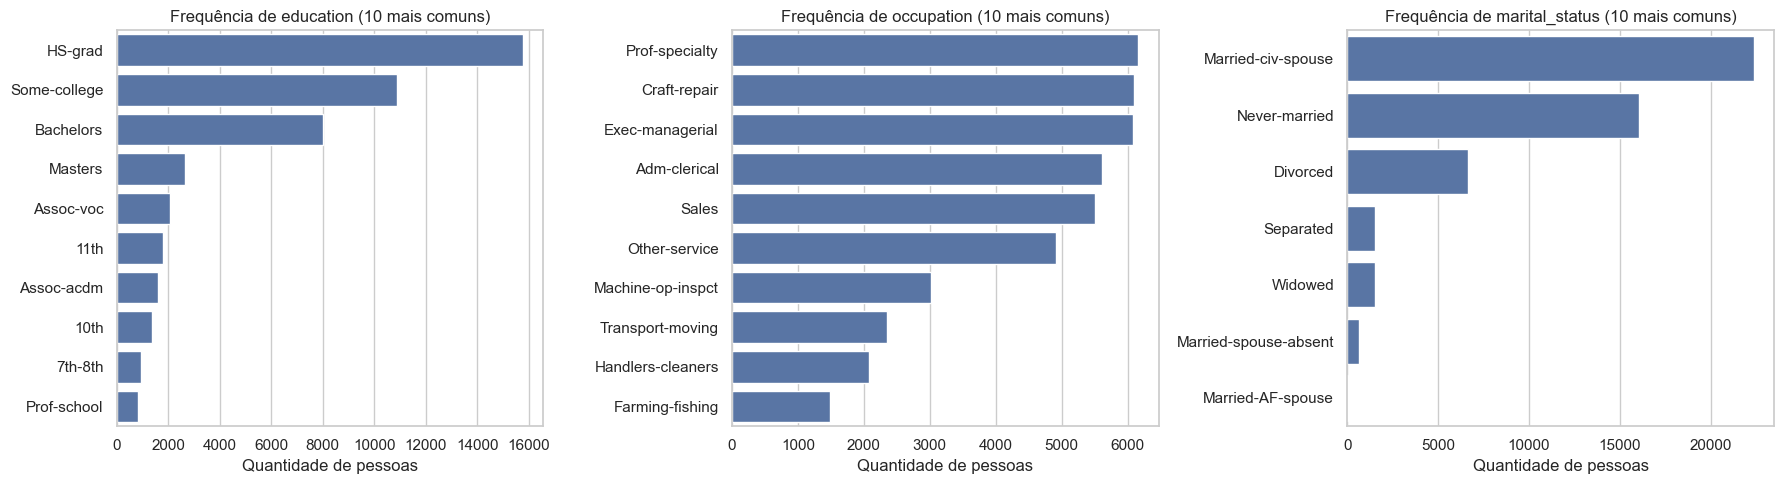

In [9]:
selected_cat = ['education', 'occupation', 'marital_status']
for col in selected_cat:
    display(data[col].value_counts(dropna=False).to_frame('frequencia').head(10))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, selected_cat):
    sns.countplot(data=data, y=col, order=data[col].value_counts().head(10).index, ax=ax)
    ax.set_title(f'Frequência de {col} (10 mais comuns)')
    ax.set_xlabel('Quantidade de pessoas')
    ax.set_ylabel('')
plt.tight_layout()
plt.show()

**Interpretação**

- `education`: *HS-grad*, *Some-college* e *Bachelors* somam cerca de 70% da base. Níveis muito baixos são raros.
- `occupation`: distribuição equilibrada entre as ocupações mais comuns, sem categoria dominante.
- `marital_status`: *Married-civ-spouse* e *Never-married* cobrem cerca de 80% dos registros.
- Nas outras categóricas, `native_country` tem 90% em *United-States* e `race` tem 85% em *White*. Categorias raras têm poucas amostras, o que limita o que o modelo aprende sobre elas.

## 3. Análise bivariada e multivariada

### 3.1 Correlação entre variáveis numéricas

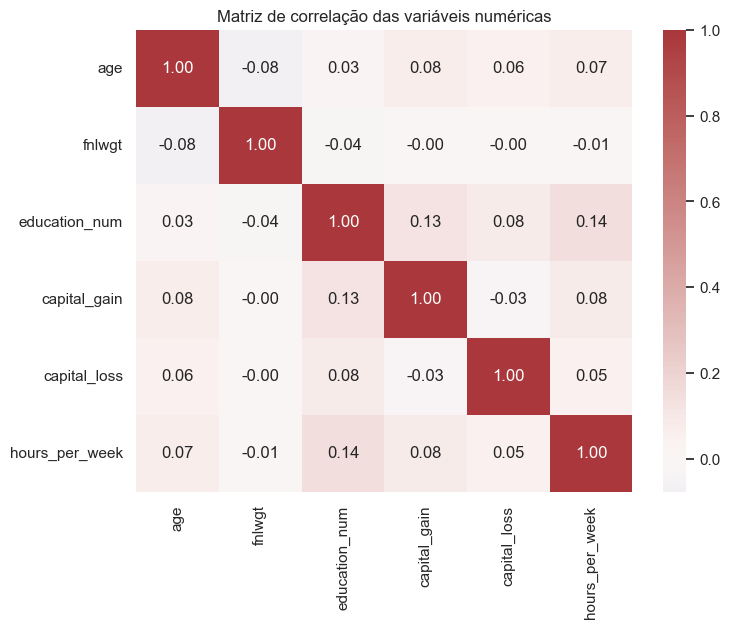

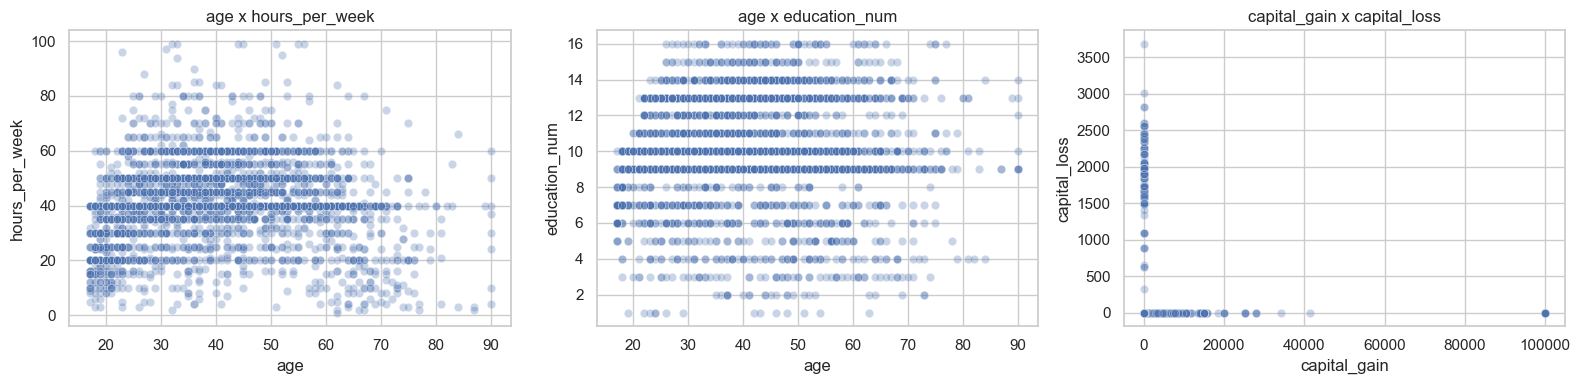

In [10]:
plt.figure(figsize=(8, 6))
sns.heatmap(data[numeric_cols].corr(), annot=True, fmt='.2f', cmap='vlag', center=0)
plt.title('Matriz de correlação das variáveis numéricas')
plt.show()

amostra = data.sample(5000, random_state=RANDOM_STATE)  # amostra para o gráfico não ficar pesado
pares = [('age', 'hours_per_week'), ('age', 'education_num'), ('capital_gain', 'capital_loss')]
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (x, y) in zip(axes, pares):
    sns.scatterplot(data=amostra, x=x, y=y, alpha=0.3, ax=ax)
    ax.set_title(f'{x} x {y}')
plt.tight_layout()
plt.show()

**Interpretação**

- Todas as correlações são **fracas** (abaixo de 0,15). Não há multicolinearidade: cada numérica traz informação própria.
- `fnlwgt` tem correlação praticamente zero com tudo, confirmando que é um artefato amostral.
- `capital_gain` e `capital_loss` são **mutuamente exclusivas**: ninguém declara ganho e perda no mesmo ano. As duas podem receber a mesma transformação.
- `age` × `education_num` não mostra tendência.

### 3.2 Variáveis categóricas × renda

income,<=50K,>50K
education,,
Prof-school,26.0,74.0
Doctorate,27.4,72.6
Masters,45.1,54.9
Bachelors,58.7,41.3
Assoc-acdm,74.2,25.8
Assoc-voc,74.7,25.3
Some-college,81.0,19.0
HS-grad,84.1,15.9
12th,92.7,7.3


income,<=50K,>50K
occupation,,
Exec-managerial,52.2,47.8
Prof-specialty,54.9,45.1
Armed-Forces,66.7,33.3
Protective-serv,68.6,31.4
Tech-support,70.9,29.1
Sales,73.2,26.8
Craft-repair,77.4,22.6
Transport-moving,79.6,20.4
Adm-clerical,86.3,13.7


income,<=50K,>50K
marital_status,,
Married-civ-spouse,55.4,44.6
Married-AF-spouse,62.2,37.8
Divorced,89.9,10.1
Married-spouse-absent,90.7,9.3
Widowed,91.6,8.4
Separated,93.5,6.5
Never-married,95.4,4.6


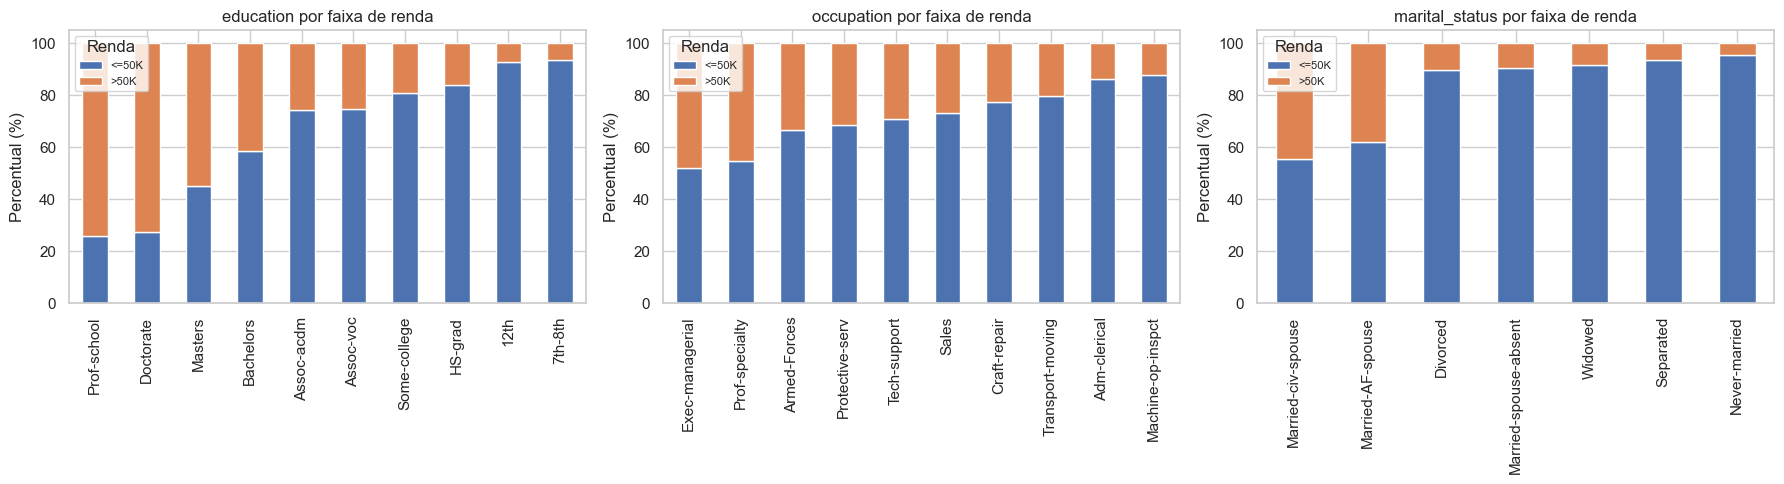

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, selected_cat):
    tabela = pd.crosstab(data[col], data['income'], normalize='index').mul(100).round(1)
    tabela = tabela.sort_values('>50K', ascending=False)
    display(tabela.head(10))
    tabela.head(10).plot(kind='bar', stacked=True, ax=ax)
    ax.set_title(f'{col} por faixa de renda')
    ax.set_xlabel('')
    ax.set_ylabel('Percentual (%)')
    ax.legend(title='Renda', fontsize=8)
plt.tight_layout()
plt.show()

**Interpretação**

- `marital_status` é a categórica mais discriminante: 45% dos casados ganham `>50K`, contra 10% dos divorciados e menos de 7% dos solteiros.
- `education` é monotônica: a taxa de `>50K` vai de menos de 10% no ensino fundamental para mais de 70% em *Doctorate* e *Prof-school*. Isso confirma que a ordem em `education_num` representa bem a variável.
- `occupation`: *Exec-managerial* e *Prof-specialty* têm 45% a 48% de `>50K`; *Other-service*, *Handlers-cleaners* e *Priv-house-serv* ficam abaixo de 7%.

### 3.3 Vieses demográficos

Este dataset é um caso clássico de viés: `sex` e `race` são fortemente associados ao alvo. Um modelo treinado nele vai reproduzir essas diferenças, então elas precisam ser declaradas e acompanhadas na avaliação (por exemplo, comparando o recall entre grupos).

In [12]:
for col in ['sex', 'race']:
    tabela = pd.crosstab(data[col], data['income'], normalize='index').mul(100).round(1)
    tabela['quantidade'] = data[col].value_counts()
    display(tabela.sort_values('>50K', ascending=False))

income,<=50K,>50K,quantidade
sex,,,
Male,69.6,30.4,32614
Female,89.1,10.9,16176


income,<=50K,>50K,quantidade
race,,,
Asian-Pac-Islander,73.0,27.0,1517
White,74.6,25.4,41714
Other,87.7,12.3,406
Black,87.9,12.1,4683
Amer-Indian-Eskimo,88.3,11.7,470


**Interpretação:** 30% dos homens estão na classe `>50K`, contra 11% das mulheres. *White* e *Asian-Pac-Islander* ficam em torno de 25%; *Black*, *Amer-Indian-Eskimo* e *Other* ficam em torno de 12%. Mulheres e minorias raciais também são minoria na base, o que dificulta ainda mais o acerto do modelo nesses grupos.

### 3.4 Variáveis numéricas × categóricas

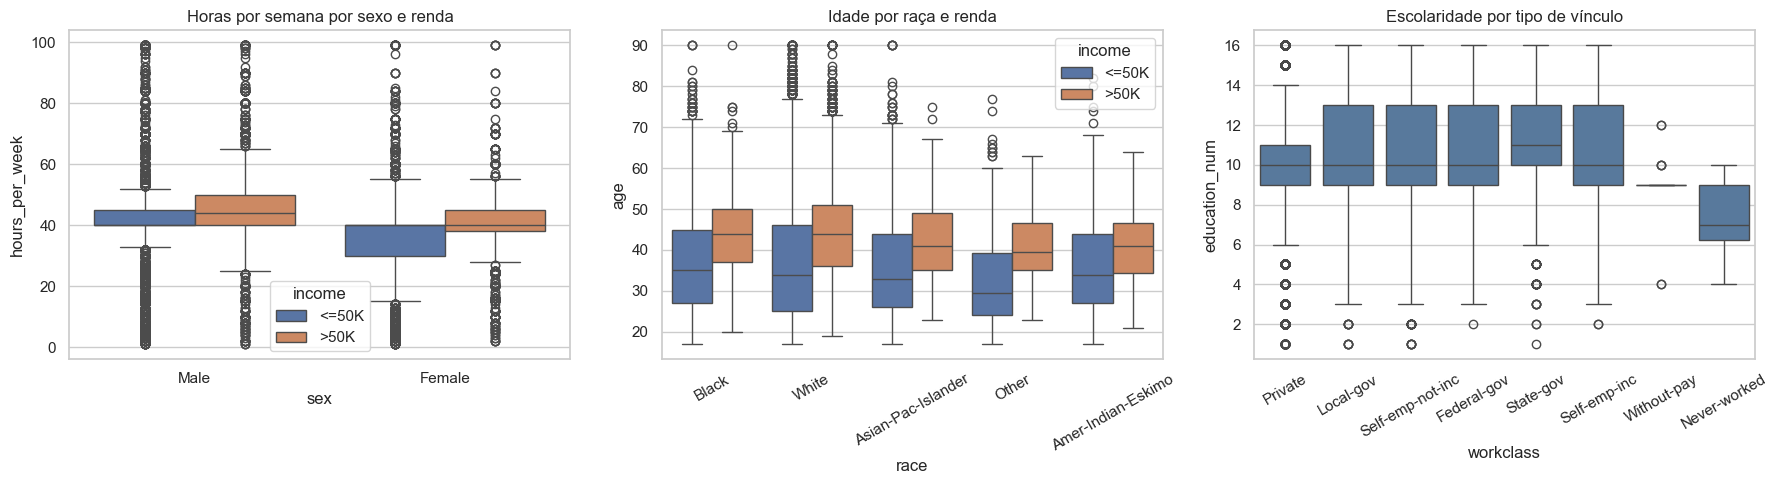

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(data=data, x='sex', y='hours_per_week', hue='income', ax=axes[0]).set_title('Horas por semana por sexo e renda')
sns.boxplot(data=data, x='race', y='age', hue='income', ax=axes[1]).set_title('Idade por raça e renda')
sns.boxplot(data=data, x='workclass', y='education_num', ax=axes[2], color='#4c78a8').set_title('Escolaridade por tipo de vínculo')
axes[1].tick_params(axis='x', rotation=30)
axes[2].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

**Interpretação**

- **Horas por sexo e renda:** entre homens, a mediana sobe de 40 h (`<=50K`) para 44 h (`>50K`). Entre mulheres, a mediana fica em 40 h nas duas classes, mas o quartil inferior sobe de 30 h para 40 h: mulheres com renda alta quase não trabalham meio período.
- **Idade por raça e renda:** em todos os grupos, a classe `>50K` é mais velha (mediana de 43 anos contra 34). A relação idade → renda é consistente entre raças.
- **Escolaridade por vínculo:** as medianas são parecidas (10), mas os vínculos de governo e os autônomos têm mais pessoas com pós-graduação (quartil superior em 13) do que *Private* (11). *Never-worked* e *Without-pay* têm escolaridade bem menor.

### 3.5 Síntese dos achados

1. **Assimetria:** `capital_gain` e `capital_loss` são muito assimétricas (mais de 90% de zeros, teto em 99999). `age` tem assimetria leve.
2. **Associados a maior renda:** ser casado, ter ensino superior ou pós, cargos executivos ou de especialista, mais de 40 h semanais e mais de 35 anos. `sex` e `race` também são associados, o que é viés.
3. **Outliers:** os extremos são reais (tetos do Censo), não erros. Serão mantidos, com transformação de escala nas variáveis de capital.
4. **Redundâncias:** `education` = `education_num`; `fnlwgt` não se relaciona com nada. Ambas serão removidas.
5. **Ausentes:** concentrados em `workclass`/`occupation` (mesmas linhas), com padrão informativo.

## 4. Pré-processamento para modelagem

### 4.1 Separação treino/teste

A divisão é feita **antes** de ajustar qualquer transformação, para que imputação, escala e categorias sejam aprendidas só no treino (sem vazamento de dados). O `stratify` preserva a proporção 3:1 nos dois conjuntos.

In [14]:
X = data.drop(columns='income')
y = data['income']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print('Treino:', X_train.shape, '| Teste:', X_test.shape)
print('Proporção >50K no treino:', round((y_train == '>50K').mean() * 100, 2), '%')
print('Proporção >50K no teste: ', round((y_test == '>50K').mean() * 100, 2), '%')

Treino: (39032, 14) | Teste: (9758, 14)
Proporção >50K no treino: 23.94 %
Proporção >50K no teste:  23.94 %


### 4.2 Estratégias escolhidas e justificativas

| Etapa | Decisão | Justificativa (achado da EDA) |
|---|---|---|
| **Remoção de features** | Descartar `education` e `fnlwgt` | `education` repete `education_num`, que já tem a ordem dos níveis. `fnlwgt` é peso amostral com correlação zero com tudo. |
| **Ausentes (categóricas)** | Imputar a categoria `Desconhecido` | A ausência em `workclass`/`occupation` identifica pessoas sem vínculo. Imputar a moda (`Private`) daria um emprego a quem não tem. |
| **Ausentes (numéricas)** | Imputar a mediana | Não há ausentes numéricos hoje, mas a etapa fica no pipeline por segurança. A mediana é robusta a outliers. |
| **Outliers** | Manter os registros e aplicar `log1p` em `capital_gain` e `capital_loss` | Os extremos são reais e muito preditivos (ganho alto quase sempre é `>50K`). Remover linhas jogaria fora casos da classe minoritária. O `log1p` comprime a cauda (99999 vira 11,5) e preserva o zero. |
| **Encoding** | One-Hot Encoding com `handle_unknown='ignore'` | As categóricas são nominais (sem ordem); *label encoding* criaria uma ordem falsa. A cardinalidade é baixa (91 colunas no total). Categorias novas no teste viram zeros em vez de erro. |
| **Escala** | `StandardScaler` (z-score) | Necessário para Regressão Logística, KNN, SVM e PCA. Min-Max seria esmagado pelos valores de teto. |

### 4.3 Pipeline de pré-processamento

In [15]:
drop_features = ['education', 'fnlwgt']
capital_features = ['capital_gain', 'capital_loss']
numeric_features = ['age', 'education_num', 'hours_per_week']
categorical_features = [c for c in X_train.columns if X_train[c].dtype == object and c not in drop_features]

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

capital_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('log1p', FunctionTransformer(np.log1p)),   # tratamento de outliers
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Desconhecido')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('numeric', numeric_pipeline, numeric_features),
    ('capital', capital_pipeline, capital_features),
    ('categorical', categorical_pipeline, categorical_features)
])  # colunas não listadas (education, fnlwgt) são descartadas

X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)
print('Treino processado:', X_train_prep.shape, '| Teste processado:', X_test_prep.shape)

Treino processado: (39032, 91) | Teste processado: (9758, 91)


### 4.4 PCA nas variáveis numéricas

O PCA usa as 5 colunas numéricas já imputadas, transformadas e padronizadas pelo pipeline (as 5 primeiras colunas da saída, na ordem `age`, `education_num`, `hours_per_week`, `capital_gain`, `capital_loss`). Ele é ajustado só no treino.

,variancia_%,acumulada_%
PC1,26.1,26.1
PC2,21.3,47.4
PC3,19.5,66.9
PC4,17.6,84.5
PC5,15.5,100.0


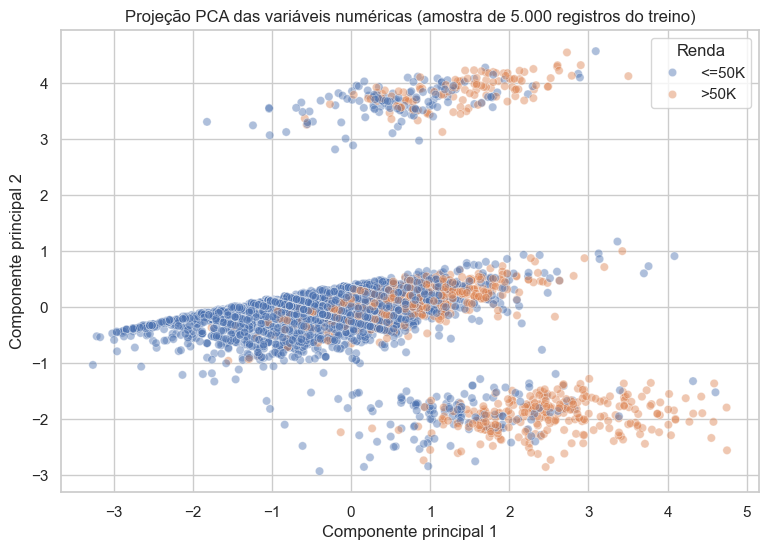

In [16]:
pca_features = numeric_features + capital_features
X_num = X_train_prep[:, :len(pca_features)]

pca = PCA(random_state=RANDOM_STATE).fit(X_num)
variancia = pd.DataFrame({
    'variancia_%': (pca.explained_variance_ratio_ * 100).round(1),
    'acumulada_%': (pca.explained_variance_ratio_.cumsum() * 100).round(1)
}, index=[f'PC{i + 1}' for i in range(len(pca_features))])
display(variancia)

componentes = pd.DataFrame(pca.transform(X_num)[:, :2], columns=['PC1', 'PC2'])
componentes['income'] = y_train.values

plt.figure(figsize=(9, 6))
sns.scatterplot(data=componentes.sample(5000, random_state=RANDOM_STATE), x='PC1', y='PC2', hue='income', alpha=0.45)
plt.title('Projeção PCA das variáveis numéricas (amostra de 5.000 registros do treino)')
plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')
plt.legend(title='Renda')
plt.show()

In [17]:
loadings = pd.DataFrame(pca.components_[:2].T, index=pca_features, columns=['PC1', 'PC2']).round(3)
display(loadings)

,PC1,PC2
age,0.411,-0.148
education_num,0.536,0.189
hours_per_week,0.520,0.149
capital_gain,0.489,-0.539
capital_loss,0.185,0.793


**Interpretação do PCA**

- **Variância explicada:** PC1 e PC2 juntas explicam menos da metade da variância (47%), e são necessárias 4 componentes para passar de 80%. Isso acontece porque as numéricas têm correlação fraca entre si, então há pouca redundância para o PCA comprimir. Na modelagem é melhor usar as variáveis originais.
- **Loadings:** PC1 combina `education_num`, `hours_per_week`, `capital_gain` e `age`, todas com sinal positivo: é um eixo de "maturidade profissional", a direção associada a `>50K`. PC2 contrasta `capital_loss` (positivo) com `capital_gain` (negativo), separando quem teve perda, quem teve ganho e quem não movimentou capital.
- **Separabilidade:** o gráfico mostra três faixas. A central (sem capital) tem a maioria das pessoas, com `>50K` deslocada para a direita mas muito sobreposta. A faixa inferior (ganho de capital) é dominada por `>50K`. A faixa superior (perda de capital) é mista. Ou seja, as numéricas separam só parcialmente as classes; as categóricas (`marital_status`, `occupation`) serão essenciais.
- **Efeito do `log1p`:** sem a transformação, os 244 registros com ganho de 99999 formariam um ponto isolado longe de todo o resto, dominando uma componente inteira.

### 4.5 Pipeline final para a etapa de classificação

Basta acoplar um classificador ao `preprocessor`. O exemplo abaixo ainda não é treinado nem avaliado; isso é a próxima etapa, em que se recomenda comparar Regressão Logística, Árvore de Decisão e Random Forest com validação cruzada estratificada e métricas de precisão, recall, F1-score e ROC-AUC.

In [18]:
from sklearn.linear_model import LogisticRegression

modelo = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE))
])
modelo

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('capital', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differe

## 5. Relatório: principais achados e estratégia proposta

**Dados**

- Cerca de 48 mil registros, 14 features (6 numéricas, 8 categóricas), alvo binário desbalanceado 3:1.
- Ausentes só em `workclass`, `occupation` e `native_country`, com padrão informativo. Poucas duplicatas, removidas.
- Sem valores impossíveis, mas com tetos do Censo em `capital_gain`, `hours_per_week` e `age`.

**Relações com o alvo**

- Preditores mais fortes: `marital_status`, `education_num`, `occupation`, `age`, `hours_per_week` e `capital_gain`.
- `fnlwgt` é irrelevante e `education` é redundante.
- As numéricas têm correlação fraca entre si; o PCA confirma que elas sozinhas separam só parcialmente as classes.
- Viés: homens e pessoas brancas têm taxa de `>50K` duas a três vezes maior que mulheres e minorias.

**Estratégia para a modelagem**

- Pipeline com remoção de `education` e `fnlwgt`; mediana + z-score nas numéricas; `log1p` + z-score nas de capital; categoria `Desconhecido` + one-hot nas categóricas.
- Split estratificado 80/20 e validação cruzada estratificada.
- Métricas focadas na classe minoritária (F1, recall, ROC-AUC), `class_weight='balanced'` e métricas separadas por sexo e raça.

## Referências

- Dataset [Adult Income Census](https://www.kaggle.com/datasets/anaghakp/adult-income-census), Kaggle. Origem: Becker, B. e Kohavi, R. (1996). *Adult* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5XW20